In [1]:
!pip install ultralytics shapely opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.8 MB/s eta 0:00:00


Image loaded successfully from GitHub.

0: 608x1024 7 large vehicles, 221 small vehicles, 607.8ms
Speed: 28.7ms preprocess, 607.8ms inference, 688.7ms postprocess per image at shape (1, 3, 608, 1024)


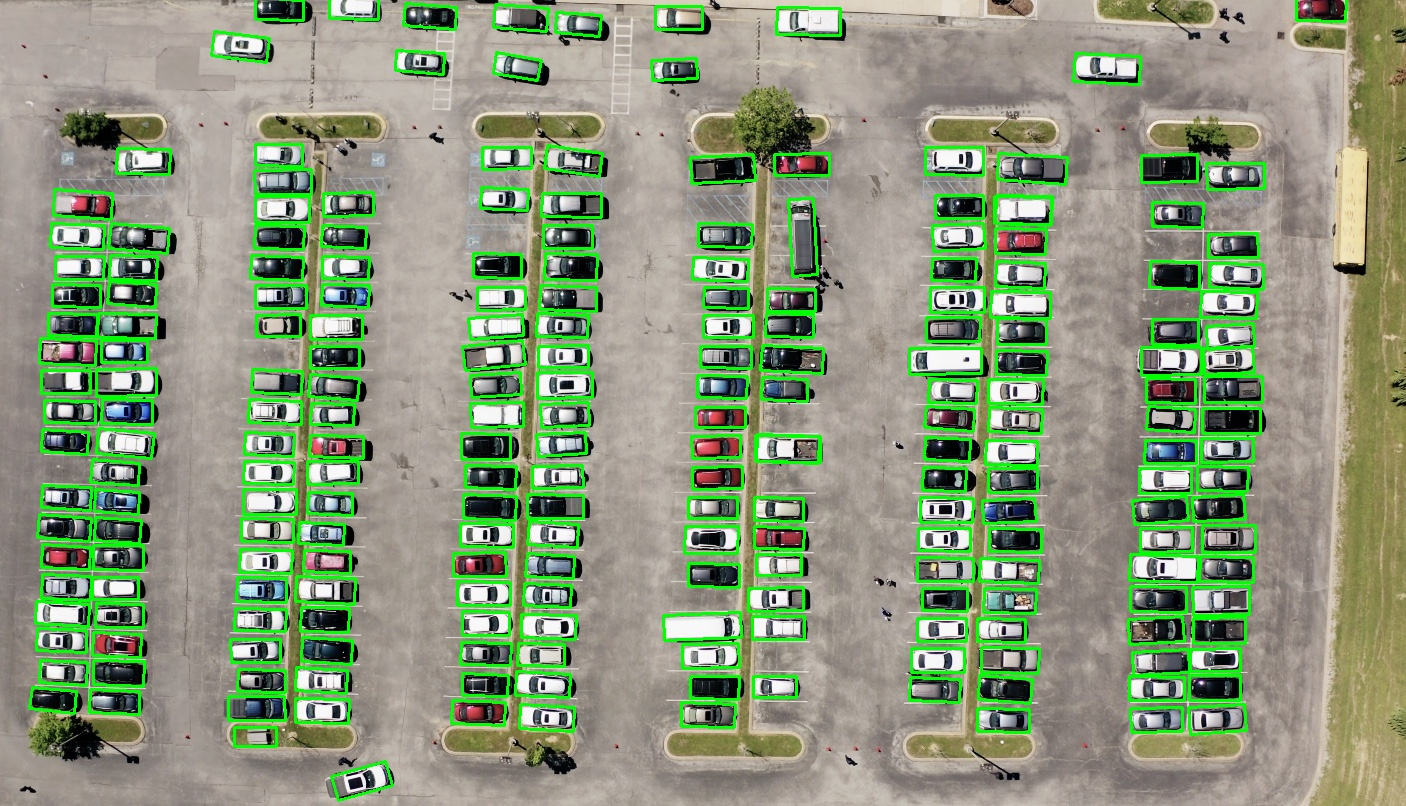

In [11]:
import os
import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from ultralytics import YOLO
from IPython.display import Image as DisplayImage, display

# GitHub image URL
parking_url = "https://raw.githubusercontent.com/MashaelAlshehir/Computer-Vision-Final-Project/main/images/parking.jpg"# Download image from GitHub
response = requests.get(parking_url)
response.raise_for_status()

# Convert image to PIL
pil_img = Image.open(BytesIO(response.content)).convert("RGB")

# Convert PIL image to OpenCV
img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

print("Image loaded successfully from GitHub.")

# Load YOLO OBB model
model = YOLO("yolov8n-obb.pt")

# Run detection
results = model(img, conf=0.25)[0]

# Draw detected OBB polygons
if results.obb is not None:
    corners = results.obb.xyxyxyxy.cpu().numpy().astype(np.int32)

    for poly in corners:
        cv2.polylines(
            img,
            [poly],
            isClosed=True,
            color=(0, 255, 0),
            thickness=2
        )

# Save and display result
output_path = "/content/obb_result.jpg"
cv2.imwrite(output_path, img)

display(DisplayImage(filename=output_path))

In [15]:
# Count parked cars
car_count = 0

if results.obb is not None:
    car_count = len(results.obb)

print(f"Number of parked cars: {car_count}")

Number of parked cars: 233


Image loaded successfully!
Image size: 1406 x 806

0: 608x1024 7 large vehicles, 221 small vehicles, 474.5ms
Speed: 9.5ms preprocess, 474.5ms inference, 982.4ms postprocess per image at shape (1, 3, 608, 1024)
Detected vehicles: 228

========== Parking Statistics ==========
Total spaces: 264
Occupied: 236
Available: 28


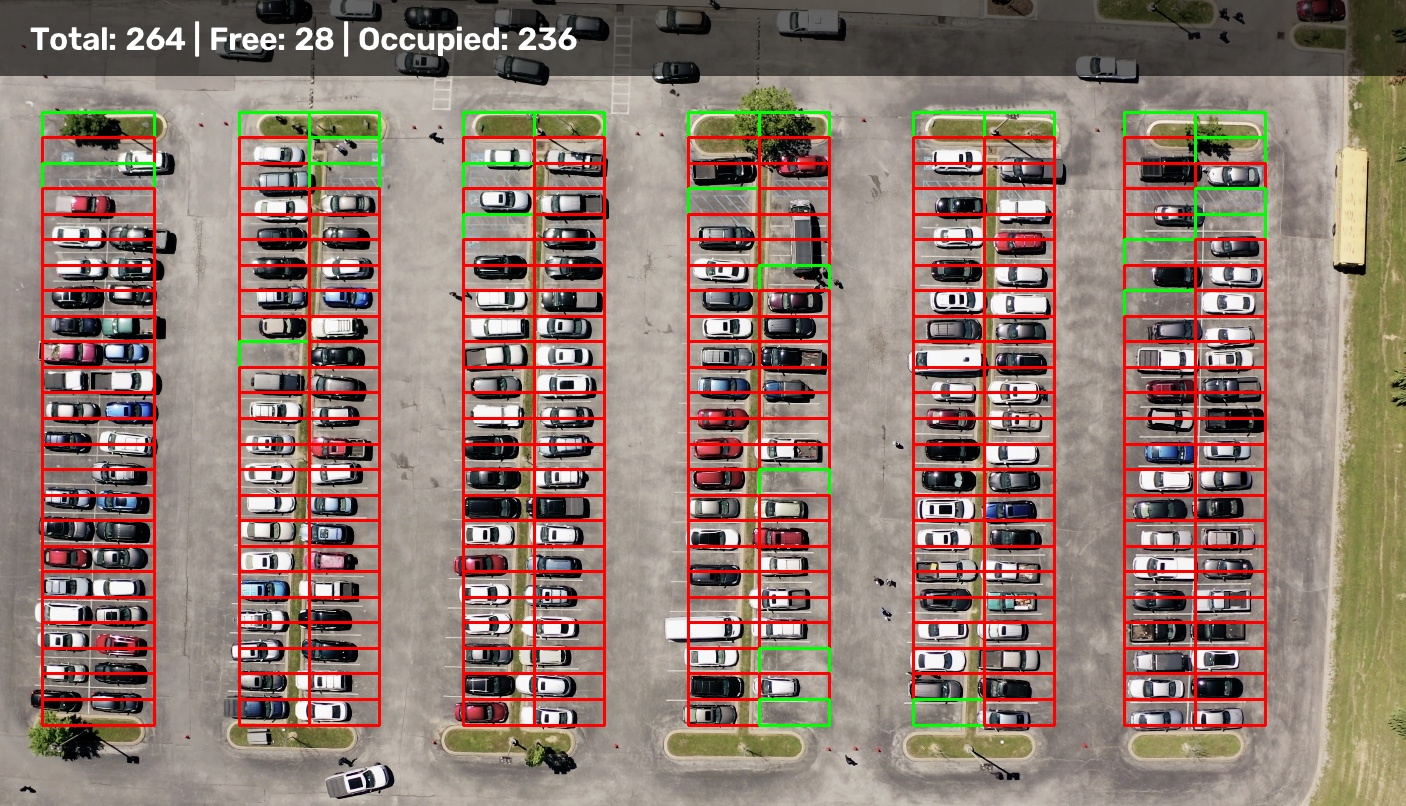

In [17]:
import cv2
import numpy as np
import requests
from io import BytesIO
from PIL import Image
from shapely.geometry import Polygon
from ultralytics import YOLO
from IPython.display import Image as DisplayImage, display

# ==========================================
# 1. Load parking image from GitHub
# ==========================================

parking_url = "https://raw.githubusercontent.com/MashaelAlshehir/Computer-Vision-Final-Project/main/images/parking.jpg"

response = requests.get(parking_url)
response.raise_for_status()

pil_img = Image.open(BytesIO(response.content)).convert('RGB')

img = cv2.cvtColor(
    np.array(pil_img),
    cv2.COLOR_RGB2BGR
)

h, w, _ = img.shape

print("Image loaded successfully!")
print("Image size:", w, "x", h)


# ==========================================
# 2. Parking measurements
# ==========================================

columns_pct = [
    (0.03, 0.11),              # الصف الأيسر

    (0.17, 0.22),
    (0.22, 0.27),              # العمود الثاني

    (0.33, 0.38),
    (0.38, 0.43),              # العمود الثالث

    (0.49, 0.54),
    (0.54, 0.59),              # العمود الرابع

    (0.65, 0.70),
    (0.70, 0.75),              # العمود الخامس

    (0.80, 0.85),
    (0.85, 0.90)               # العمود السادس
]

y_min = int(h * 0.14)
y_max = int(h * 0.90)

num_rows = 24

parking_spots = []

for x_start_pct, x_end_pct in columns_pct:

    x1 = int(w * x_start_pct)
    x2 = int(w * x_end_pct)

    row_height = (y_max - y_min) / num_rows

    for i in range(num_rows):

        y1 = int(y_min + i * row_height)
        y2 = int(y_min + (i + 1) * row_height)

        spot_poly = np.array([
            [x1, y1],
            [x2, y1],
            [x2, y2],
            [x1, y2]
        ], np.int32)

        parking_spots.append(spot_poly)


# ==========================================
# 3. YOLO OBB vehicle detection
# ==========================================

model = YOLO("yolov8n-obb.pt")

results = model(
    img,
    conf=0.20
)[0]


# ==========================================
# 4. Get detected vehicles
# ==========================================

detected_vehicles = []

if results.obb is not None:

    for obb in results.obb.xyxyxyxy.cpu().numpy():

        vehicle_polygon = Polygon(obb)

        detected_vehicles.append(
            vehicle_polygon
        )

print("Detected vehicles:", len(detected_vehicles))


# ==========================================
# 5. Check parking occupancy
# ==========================================

free_count = 0
occupied_count = 0

iou_threshold = 0.18


for spot in parking_spots:

    spot_polygon = Polygon(spot)

    is_occupied = False

    for vehicle_poly in detected_vehicles:

        if spot_polygon.intersects(vehicle_poly):

            intersection_area = (
                spot_polygon
                .intersection(vehicle_poly)
                .area
            )

            coverage = (
                intersection_area /
                spot_polygon.area
            )

            if coverage >= iou_threshold:

                is_occupied = True
                break


    # ======================================
    # Color parking space
    # ======================================

    if is_occupied:

        occupied_count += 1

        # RED = Occupied
        color = (0, 0, 255)

    else:

        free_count += 1

        # GREEN = Available
        color = (0, 255, 0)


    cv2.polylines(
        img,
        [spot],
        isClosed=True,
        color=color,
        thickness=2
    )


# ==========================================
# 6. Statistics
# ==========================================

total_spaces = len(parking_spots)

print()
print("========== Parking Statistics ==========")
print("Total spaces:", total_spaces)
print("Occupied:", occupied_count)
print("Available:", free_count)
print("=========================================")


# ==========================================
# 7. Add statistics to image
# ==========================================

overlay = img.copy()

cv2.rectangle(
    overlay,
    (0, 0),
    (w, 75),
    (0, 0, 0),
    -1
)

img = cv2.addWeighted(
    overlay,
    0.6,
    img,
    0.4,
    0
)

stats = (
    f"Total: {total_spaces} | "
    f"Free: {free_count} | "
    f"Occupied: {occupied_count}"
)

cv2.putText(
    img,
    stats,
    (30, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.1,
    (255, 255, 255),
    3
)


# ==========================================
# 8. Save and display
# ==========================================

output_path = "/content/parking_grid_result.jpg"

cv2.imwrite(
    output_path,
    img
)

display(
    DisplayImage(
        filename=output_path
    )
)